In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import export_text
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt
import xgboost as xgb

In [2]:
url = "https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv"

In [3]:
df = pd.read_csv(url)

In [4]:
df.fillna(0, inplace=True)

In [5]:
df_full_train, df_test = train_test_split(df, test_size=.2, random_state=1)
df_train, df_val = train_test_split(df, test_size=.25, random_state=1)

In [6]:
def one_hot_encoding(df, enc=None):
	df.reset_index(drop=True, inplace=True)
	df_categorical = df.select_dtypes(exclude='number')
	df_numerical = df.select_dtypes('number')

	if not enc:
		enc = OneHotEncoder(sparse_output=False, dtype=np.int32)
		enc.fit(df_categorical)

	df_encoded = pd.DataFrame(
		data=enc.transform(df_categorical),
		columns=enc.get_feature_names_out())

	X = pd.concat([df_encoded, df_numerical], axis=1)

	return X, enc

In [7]:
X_train, enc = one_hot_encoding(df_train)
X_val, _ = one_hot_encoding(df_val, enc)
X_test, _ = one_hot_encoding(df_test)

In [8]:
y_train = X_train.fuel_efficiency_mpg
y_val = X_val.fuel_efficiency_mpg
y_test = X_test.fuel_efficiency_mpg

X_train.drop('fuel_efficiency_mpg', axis=1, inplace=True)
X_val.drop('fuel_efficiency_mpg', axis=1, inplace=True)
X_test.drop('fuel_efficiency_mpg', axis=1, inplace=True)

## Question 1

In [9]:
dt = DecisionTreeRegressor(max_depth=1)
dt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=1)

In [10]:
print(export_text(dt, feature_names=list(X_train.columns)))

|--- vehicle_weight <= 3025.74
|   |--- value: [16.86]
|--- vehicle_weight >  3025.74
|   |--- value: [12.88]



## Question 2

In [11]:
rf = RandomForestRegressor(n_estimators=10, random_state=1, n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=10, n_jobs=-1, random_state=1)

In [12]:
y_pred = rf.predict(X_val)
rmse = root_mean_squared_error(y_val, y_pred)

In [13]:
print(f"Random forest validation RMSE: {rmse:.3f}")

Random forest validation RMSE: 0.449


## Question 3

In [14]:
scores = []

In [15]:
for n in range(10, 200, 10):
	rf = RandomForestRegressor(n_estimators=n, random_state=1, n_jobs=-1)
	rf.fit(X_train, y_train)

	y_pred = rf.predict(X_val)
	rmse = root_mean_squared_error(y_val, y_pred)
	scores.append((n, rmse))

In [16]:
df_scores = pd.DataFrame(scores, columns=['n_estimators', 'rmse'])

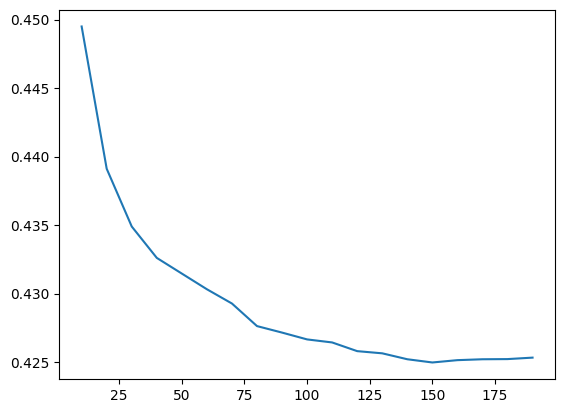

In [17]:
plt.plot(df_scores.n_estimators, df_scores.rmse)
plt.show()

## Question 4

In [18]:
scores = []

for m in [10, 15, 20, 25]:
	for n in range(10, 200, 10):
		rf = RandomForestRegressor(n_estimators=n, max_depth=m, random_state=1, n_jobs=-1)
		rf.fit(X_train, y_train)

		y_pred = rf.predict(X_val)
		rmse = root_mean_squared_error(y_val, y_pred)
		scores.append((n, m, rmse))

In [19]:
df_scores = pd.DataFrame(scores, columns=['n_estimators', 'max_depth', 'rmse'])

In [20]:
df_scores.loc[df_scores.rmse == df_scores.rmse.min(), :]

,n_estimators,max_depth,rmse
14,150,10,0.423231


## Question 5

In [21]:
rf = RandomForestRegressor(n_estimators=10, max_depth=20, random_state=1, n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, n_estimators=10, n_jobs=-1, random_state=1)

In [22]:
feature_importance_df = pd.DataFrame(
	data=zip(rf.feature_names_in_, rf.feature_importances_),
	columns=['feature', 'importance']
)

In [23]:
feature_importance_df.sort_values('importance', ascending=False)[:4]

,feature,importance
10,vehicle_weight,0.959283
9,horsepower,0.015302
11,acceleration,0.011885
12,model_year,0.003421


## Gradient Boosting

In [24]:
features = list(X_train.columns)
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)

In [25]:
watchlist = [(dtrain, 'train'), (dval, 'val')]

In [26]:
def parse_xgb_output(output):
    results = []

    for line in output.stdout.strip().split('\n'):
        it_line, train_line, val_line = line.split('\t')

        it = int(it_line.strip('[]'))
        train = float(train_line.split(':')[1])
        val = float(val_line.split(':')[1])

        results.append((it, train, val))

    columns = ['num_iter', 'train_rmse', 'val_rmse']
    df_results = pd.DataFrame(results, columns=columns)
    return df_results

In [27]:
xgb_params = {
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'reg:squarederror',
    'nthread': 8,

    'seed': 1,
    'verbosity': 1,
}

In [28]:
%%capture output
model = xgb.train(xgb_params, dtrain, num_boost_round=100, verbose_eval=5, evals=watchlist)

In [29]:
scores = {}

In [30]:
key = f"eta={xgb_params['eta']}"
scores[key] = parse_xgb_output(output)

In [31]:
y_pred = model.predict(dval)
rmse = root_mean_squared_error(y_val, y_pred)
print(f"eta: {xgb_params['eta']} | RMSE: {rmse:.3f}")

eta: 0.3 | RMSE: 0.441


In [32]:
xgb_params = {
    'eta': 0.1,
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'reg:squarederror',
    'nthread': 8,

    'seed': 1,
    'verbosity': 1,
}

In [33]:
%%capture output
model = xgb.train(xgb_params, dtrain, num_boost_round=100, verbose_eval=5, evals=watchlist)

In [34]:
y_pred = model.predict(dval)
rmse = root_mean_squared_error(y_val, y_pred)
print(f"eta: {xgb_params['eta']} | RMSE: {rmse:.3f}")

eta: 0.1 | RMSE: 0.415


In [35]:
key = f"eta={xgb_params['eta']}"
scores[key] = parse_xgb_output(output)

In [36]:
scores['eta=0.3'].val_rmse.min()

np.float64(0.41956)

In [37]:
scores['eta=0.1'].val_rmse.min()

np.float64(0.41306)